# Compositional Diffusion with Guided Search

This notebook implements Compositional Diffusion with Guided Search (CDGS), a structured
inference-time algorithm designed to identify coherent sequences of local modes that form valid
long-horizon global plans. CDGS integrates population-based search, iterative resampling for
information exchange across distant segments, and a pruning/ranking objective that suppresses
incoherent global plan candidates. The whole procedure runs inside a standard denoising diffusion
process, making CDGS a plug-and-play sampler for diverse domains. The goal of this notebook is to 
provide a clean and clear implementation of CDGS for the toy domain.

Notebook organization
- Setup and imports
- Model architectures and utilities (simple 2D U-Net used for experiments)
- Data loading and small synthetic dataset utilities
- CDGS implementation (compositional sampling, iterative resampling, local-feasibility based pruning)
- Visualization and analysis utilities
- Tests and example runs that reproduce figures used in the paper for toy-domain

In [1]:
# install libraries using pip if not already installed
# Use the IPython-friendly magic `%pip` so the environment used by the kernel gets the packages.
%pip install torch==2.8.0 numpy matplotlib pandas "diffusers>=0.35.1" scipy


Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries and Setup

First, let's import all necessary libraries and set up our environment.

In [2]:
# Core libraries
from typing import List, Dict, Optional
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm import tqdm
from scipy.stats import norm

# Diffusers imports: prefer scheduler-specific import paths to satisfy static checkers
# DDPMScheduler is provided under diffusers.schedulers.scheduling_ddpm in some versions.
try:
    from diffusers import DDPMScheduler
except Exception:
    from diffusers.schedulers.scheduling_ddpm import DDPMScheduler

# Utility from diffusers for reproducible noise sampling
from diffusers.utils.torch_utils import randn_tensor

# Set up device and random seeds

def seed_everything(seed: int = 42) -> None:
    """Set Python, NumPy and PyTorch seeds for reproducible experiments.

    Args:
        seed: integer seed for RNGs.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True


# Configure device between CUDA, MPS, and CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else "cpu"
)
print(f"Using device: {device}")

# Set seed for reproducibility
seed_everything(42)

# Create output directories used by plotting utilities
os.makedirs("results_notebook", exist_ok=True)
os.makedirs("figures_notebook", exist_ok=True)

print("✅ Libraries imported and environment set up successfully!")

/Users/utkarshmishra/gsc_extension_project/notebook_release/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps
✅ Libraries imported and environment set up successfully!


## 2. Model Architecture Definition and Training utils

Let's define our model architectures. For this toy domain, we use simple 2D U-Net models that can work with both diffusion and flow matching paradigms.

In [3]:
class TimeEmbedding(nn.Module):
    """Sinusoidal time embedding for diffusion timesteps."""
    
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        
    def forward(self, time: torch.Tensor) -> torch.Tensor:
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class MLPBlock(nn.Module):
    """MLP block with time conditioning."""
    
    def __init__(self, input_dim: int, hidden_dim: int, time_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(input_dim)
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.time_proj = nn.Linear(time_dim, hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, input_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        residual = x
        
        # First layer with time conditioning
        x = self.norm1(x)
        x = F.silu(self.linear1(x) + self.time_proj(time_emb))
        x = self.dropout(x)
        
        # Second layer
        x = self.norm2(x)
        x = self.linear2(x)
        x = self.dropout(x)
        
        return x + residual


class Simple2DUNet(nn.Module):
    """
    Simple UNet-like architecture for 2D diffusion model.
    Takes 2D points and timestep, outputs noise prediction.
    """
    
    def __init__(
        self, 
        input_dim: int = 2,
        hidden_dims: tuple[int, ...] = (128, 256, 512),
        time_embed_dim: int = 128,
        num_blocks_per_level: int = 2,
        dropout: float = 0.1
    ):
        super().__init__()
        self.input_dim = input_dim
        self.time_embed_dim = time_embed_dim
        
        # Time embedding
        self.time_embedding = TimeEmbedding(time_embed_dim)
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, hidden_dims[0])
        
        # Encoder (downsampling)
        self.encoder_blocks = nn.ModuleList()
        self.encoder_downs = nn.ModuleList()
        
        for i, hidden_dim in enumerate(hidden_dims):
            blocks = nn.ModuleList([
                MLPBlock(hidden_dim, hidden_dim * 2, time_embed_dim, dropout)
                for _ in range(num_blocks_per_level)
            ])
            self.encoder_blocks.append(blocks)
            
            if i < len(hidden_dims) - 1:
                self.encoder_downs.append(nn.Linear(hidden_dim, hidden_dims[i + 1]))
        
        # Middle block
        self.middle_block = MLPBlock(hidden_dims[-1], hidden_dims[-1] * 2, time_embed_dim, dropout)
        
        # Decoder (upsampling)
        self.decoder_ups = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()
        
        reversed_dims = list(reversed(hidden_dims))
        for i, hidden_dim in enumerate(reversed_dims[:-1]):
            next_dim = reversed_dims[i + 1]
            self.decoder_ups.append(nn.Linear(hidden_dim, next_dim))
            
            # After concatenation with skip connection, we have next_dim * 2
            # We need to project it back to next_dim for the residual connection
            concat_proj = nn.Linear(next_dim * 2, next_dim)
            blocks = nn.ModuleList([
                concat_proj,  # Project concatenated features back to next_dim
                *[MLPBlock(next_dim, next_dim * 2, time_embed_dim, dropout) 
                  for _ in range(num_blocks_per_level)]
            ])
            self.decoder_blocks.append(blocks)
        
        # Output projection
        self.output_proj = nn.Linear(hidden_dims[0], input_dim)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x: torch.Tensor, timestep: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input tensor of shape (batch_size, 2)
            timestep: Timestep tensor of shape (batch_size,)
            
        Returns:
            Noise prediction of shape (batch_size, 2)
        """
        # Time embedding
        time_emb = self.time_embedding(timestep)
        
        # Input projection
        x = self.input_proj(x)
        
        # Encoder with skip connections
        skip_connections = []
        for blocks, down in zip(self.encoder_blocks[:-1], self.encoder_downs):
            for block in blocks:
                x = block(x, time_emb)
            skip_connections.append(x)
            x = F.silu(down(x))
        
        # Last encoder block (no downsampling)
        for block in self.encoder_blocks[-1]:
            x = block(x, time_emb)
        
        # Middle block
        x = self.middle_block(x, time_emb)

        # print("Middle block output shape:", x.shape)
        
        # Decoder with skip connections
        for up, blocks, skip in zip(self.decoder_ups, self.decoder_blocks, reversed(skip_connections)):
            x = F.silu(up(x))
            # print("Decoder upsample output shape:", x.shape)
            # print("Skip connection shape:", skip.shape)
            x = torch.cat([x, skip], dim=-1)  # Skip connection
            # print("After concatenation shape:", x.shape)
            
            # First block is the projection layer
            concat_proj = blocks[0]
            x = concat_proj(x)
            # print("After projection shape:", x.shape)
            
            # Apply remaining MLP blocks
            for block in blocks[1:]:
                x = block(x, time_emb)
            # print("Decoder block output shape:", x.shape)
        
        # Output projection
        x = self.output_proj(x)
        
        return x


class SimpleDiffusionModel(nn.Module):
    """
    Complete diffusion model with DDPM scheduler integration.
    """
    
    def __init__(
        self,
        unet: Optional[nn.Module] = None,
        input_dim: int = 2,
        **unet_kwargs
    ):
        super().__init__()
        self.input_dim = input_dim
        
        if unet is None:
            self.unet = Simple2DUNet(input_dim=input_dim, **unet_kwargs)
        else:
            self.unet = unet
    
    def forward(self, x: torch.Tensor, timestep: torch.Tensor) -> torch.Tensor:
        """Forward pass through the model."""
        return self.unet(x, timestep)
    
    def training_step(self, batch: torch.Tensor, noise_scheduler) -> torch.Tensor:
        """
        Training step for diffusion model.
        
        Args:
            batch: Clean data of shape (batch_size, input_dim)
            noise_scheduler: DDPM scheduler from diffusers
            
        Returns:
            Loss tensor
        """
        batch_size = batch.shape[0]
        device = batch.device
        
        # Sample random timesteps
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (batch_size,), device=device, dtype=torch.long
        )
        
        # Sample noise
        noise = torch.randn_like(batch)
        
        # Add noise to clean images according to timestep
        noisy_batch = noise_scheduler.add_noise(batch, noise, timesteps)
        
        # Predict noise
        noise_pred = self(noisy_batch, timesteps)
        
        # Compute loss (MSE between predicted and actual noise)
        loss = F.mse_loss(noise_pred, noise)
        
        return loss
    
    @torch.no_grad()
    def sample(
        self, 
        batch_size: int, 
        noise_scheduler,
        device: torch.device,
        num_inference_steps: int = 50
    ) -> torch.Tensor:
        """
        Generate samples using DDPM sampling.
        
        Args:
            batch_size: Number of samples to generate
            noise_scheduler: DDPM scheduler from diffusers
            device: Device to run on
            num_inference_steps: Number of denoising steps
            
        Returns:
            Generated samples of shape (batch_size, input_dim)
        """
        # Start with random noise
        sample = torch.randn((batch_size, self.input_dim), device=device)
        
        # Set timesteps
        noise_scheduler.set_timesteps(num_inference_steps)
        
        # Denoising loop
        for t in noise_scheduler.timesteps:
            # Predict noise
            noise_pred = self(sample, t.expand(batch_size).to(device))
            
            # Denoise
            sample = noise_scheduler.step(noise_pred, t, sample).prev_sample
        
        return sample
    
class FlowMatchingModel(nn.Module):
    """
    Complete flow matching model.
    """
    
    def __init__(
        self,
        unet: Optional[nn.Module] = None,
        input_dim: int = 2,
        **unet_kwargs
    ):
        super().__init__()
        self.input_dim = input_dim
        
        if unet is None:
            self.unet = Simple2DUNet(input_dim=input_dim, **unet_kwargs)
        else:
            self.unet = unet
    
    def forward(self, x: torch.Tensor, timestep: torch.Tensor) -> torch.Tensor:
        """Forward pass returns the predicted velocity vector."""
        return self.unet(x, timestep)
    
    def training_step(self, batch: torch.Tensor) -> torch.Tensor:
        """
        Training step for Conditional Flow Matching.
        
        Args:
            batch: Clean data x_1 of shape (batch_size, input_dim)
            
        Returns:
            Loss tensor
        """
        # 1. Sample from prior (x_0) and data (x_1)
        x_1 = batch
        x_0 = torch.randn_like(x_1) # Sample from N(0, I)
        
        # 2. Sample random time t ~ U[0, 1]
        t = torch.rand(x_1.shape[0], device=x_1.device).unsqueeze(-1)
        
        # 3. Form the interpolated point x_t
        x_t = t * x_1 + (1 - t) * x_0
        
        # 4. Define the target vector field u_t
        u_t = x_1 - x_0
        
        # 5. Predict the vector field v_t using the model
        v_pred = self(x_t, t.squeeze(-1))
        
        # 6. Compute loss (MSE between predicted and target vector field)
        loss = F.mse_loss(v_pred, u_t)
        
        return loss
    
    @torch.no_grad()
    def sample(
        self, 
        batch_size: int, 
        device: torch.device,
        num_inference_steps: int = 100
    ) -> torch.Tensor:
        """
        Generate samples using ODE integration (Euler method).
        
        Args:
            batch_size: Number of samples to generate
            device: Device to run on
            num_inference_steps: Number of integration steps
            
        Returns:
            Generated samples of shape (batch_size, input_dim)
        """
        # Start with random noise from the prior distribution at t=0
        sample = torch.randn((batch_size, self.input_dim), device=device)
        
        # Define the time steps for integration
        timesteps = torch.linspace(0, 1, num_inference_steps, device=device)
        dt = timesteps[1] - timesteps[0]
        
        # ODE integration loop
        for t in timesteps[:-1]:
            # Predict the velocity vector v(x_t, t)
            velocity = self(sample, t.expand(batch_size))
            
            # Update the sample using one step of the Euler method
            # x_{t+dt} = x_t + v(x_t, t) * dt
            sample = sample + velocity * dt
        
        return sample


# Example usage and factory functions
def create_simple_diffusion_model(
    input_dim: int = 2,
    hidden_dims: tuple[int, ...] = (128, 256, 512),
    time_embed_dim: int = 128,
    num_blocks_per_level: int = 2,
    dropout: float = 0.1
) -> SimpleDiffusionModel:
    """Create a simple diffusion model for 2D data."""
    return SimpleDiffusionModel(
        input_dim=input_dim,
        hidden_dims=hidden_dims,
        time_embed_dim=time_embed_dim,
        num_blocks_per_level=num_blocks_per_level,
        dropout=dropout
    )

def create_flow_matching_model(
    input_dim: int = 2,
    hidden_dims: tuple[int, ...] = (128, 256, 512),
    time_embed_dim: int = 128,
    num_blocks_per_level: int = 2,
    dropout: float = 0.1
) -> FlowMatchingModel:
    """Create a flow matching model for 2D data."""
    return FlowMatchingModel(
        input_dim=input_dim,
        hidden_dims=hidden_dims,
        time_embed_dim=time_embed_dim,
        num_blocks_per_level=num_blocks_per_level,
        dropout=dropout
    )

print("✅ Model architectures defined successfully!")
print(f"Simple2DUNet parameters: {sum(p.numel() for p in Simple2DUNet().parameters())}")

✅ Model architectures defined successfully!
Simple2DUNet parameters: 5770370


## 3. Training of Diffusion or Flow-Based Models

This section provides example training loops for both diffusion and flow matching models using a synthetic multimodal 2D dataset. The code demonstrates how to set up the dataset, initialize the models, configure optimizers and schedulers, and periodically save checkpoints and generated samples for visualization. You can choose to train either a diffusion model or a flow matching model by running the corresponding cells below.

Starting training loop...


Loss: 0.2893:  25%|██▌       | 50/200 [00:50<02:13,  1.12it/s]

Generated samples shape: torch.Size([1000, 2])


Loss: 0.1446:  50%|█████     | 100/200 [01:40<01:34,  1.05it/s]

Generated samples shape: torch.Size([1000, 2])


Loss: 0.1569:  75%|███████▌  | 150/200 [02:27<00:45,  1.10it/s]

Generated samples shape: torch.Size([1000, 2])


Loss: 0.0809: 100%|█████████▉| 199/200 [03:13<00:00,  1.09it/s]

Generated samples shape: torch.Size([1000, 2])


Loss: 0.0809: 100%|██████████| 200/200 [03:14<00:00,  1.03it/s]


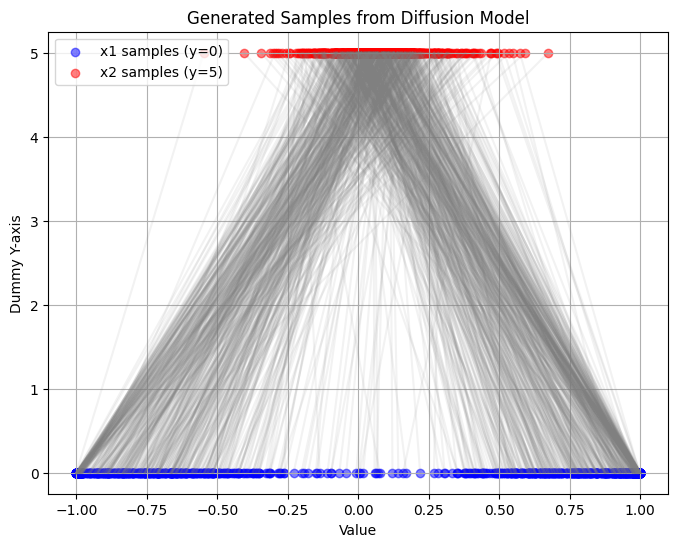

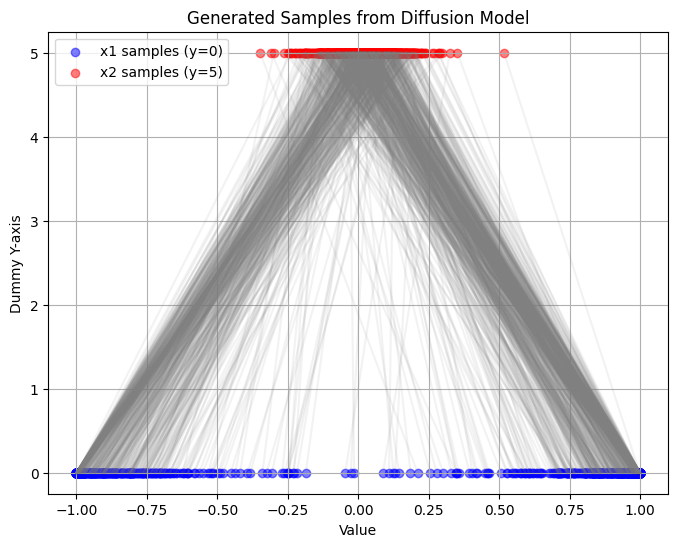

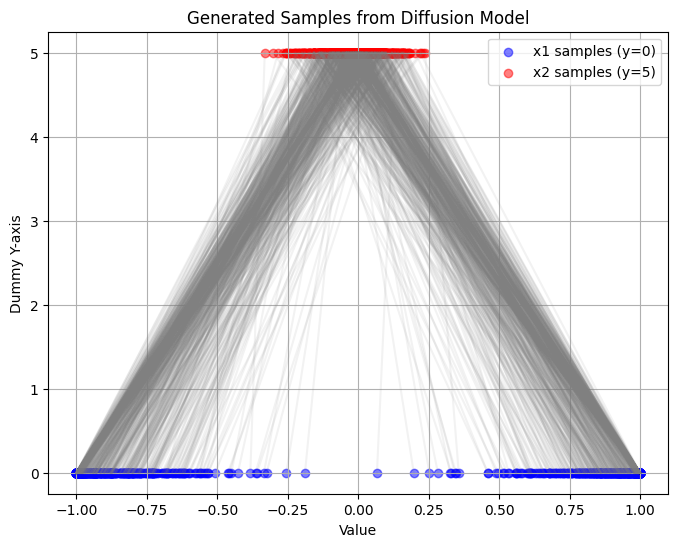

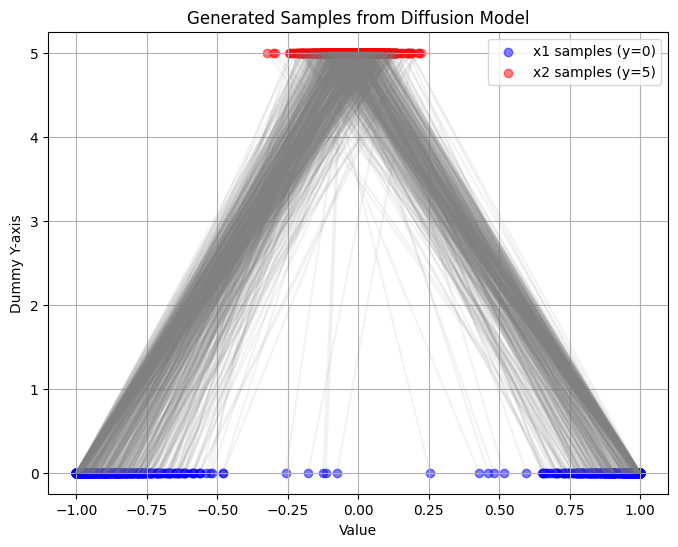

In [4]:
# Optional training loop for the diffusion model
from dataset import MultiModal2DDataset

print("Starting training loop...")
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Create dataset and dataloader
custom_matrix = np.array([
    [1],  # Mode 0 of x1 can pair with mode 0,1 of x2
    [1]
], dtype=bool)

dataset_custom = MultiModal2DDataset(
    num_samples=10000,
    num_modes_x1=2,
    num_modes_x2=1,
    mode_spacing_x1=2.0,
    mode_spacing_x2=1.5,
    mode_std_x1=0.2,
    mode_std_x2=0.1,
    transition_matrix=custom_matrix
)
dataloader = DataLoader(dataset_custom, batch_size=256, shuffle=True)

# Create model
model = create_simple_diffusion_model()

# Create scheduler
scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear"
)

model.to(device)
# Training loop (simplified)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 200

# make relevant directories
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("training", exist_ok=True)

pbar = tqdm(range(num_epochs), desc="Loss: 0.0")
for epoch in pbar:
    for batch in tqdm(dataloader, total=len(dataloader), leave=False):
        optimizer.zero_grad()
        batch = batch.to(device)
        loss = model.training_step(batch, scheduler)  # batch[0] contains the data points
        loss.backward()
        optimizer.step()
    
    # update the description of the outer
    pbar.set_description(f"Loss: {loss.item():.4f}")

    # save model
    if (epoch % 50 == 0 and epoch > 0) or epoch == num_epochs - 1:
        torch.save(model.state_dict(), "checkpoints/simple_diffusion_model.pth")

        # Sampling
        samples = model.sample(
            batch_size=1000,
            noise_scheduler=scheduler,
            device=device,
            num_inference_steps=50
        )

        print("Generated samples shape:", samples.shape)

        # ploy x1 at y= 0 and x2 at y=5, join with lines
        import matplotlib.pyplot as plt
        x1_samples = samples[:, 0].cpu().numpy()
        x2_samples = samples[:, 1].cpu().numpy()
        plt.figure(figsize=(8, 6))
        plt.scatter(x1_samples, np.zeros_like(x1_samples), color='blue', alpha=0.5, label='x1 samples (y=0)')
        plt.scatter(x2_samples, np.ones_like(x2_samples) * 5, color='red', alpha=0.5, label='x2 samples (y=5)')
        for i in range(len(x1_samples)):
            plt.plot([x1_samples[i], x2_samples[i]], [0, 5], color='gray', alpha=0.1)
        plt.title('Generated Samples from Diffusion Model')
        plt.xlabel('Value')
        plt.ylabel('Dummy Y-axis')
        plt.legend()
        plt.grid()
        plt.savefig(f"training/generated_samples_epoch_{epoch}.png")


Starting training loop...


Loss: 0.8973:  25%|██▌       | 50/200 [00:45<02:22,  1.05it/s]

Generated samples shape: torch.Size([1000, 2])


Loss: 0.8057:  50%|█████     | 100/200 [01:30<01:27,  1.15it/s]

Generated samples shape: torch.Size([1000, 2])


Loss: 0.5295:  75%|███████▌  | 150/200 [02:14<00:42,  1.18it/s]

Generated samples shape: torch.Size([1000, 2])


Loss: 1.0923: 100%|█████████▉| 199/200 [02:58<00:00,  1.14it/s]

Generated samples shape: torch.Size([1000, 2])


Loss: 1.0923: 100%|██████████| 200/200 [02:59<00:00,  1.11it/s]


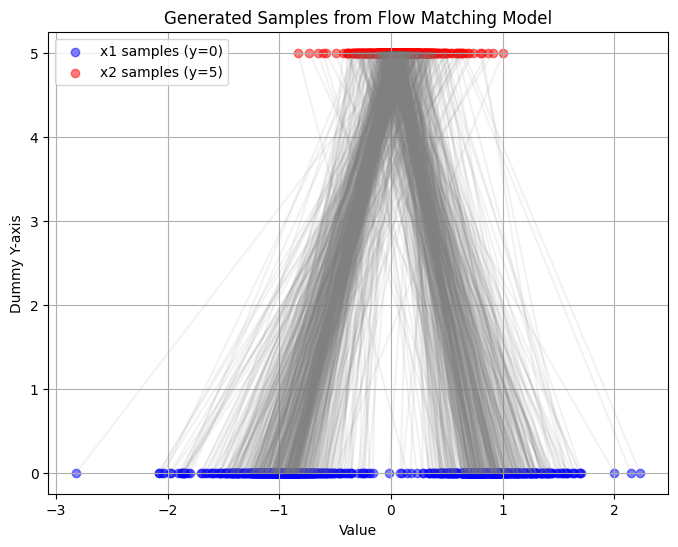

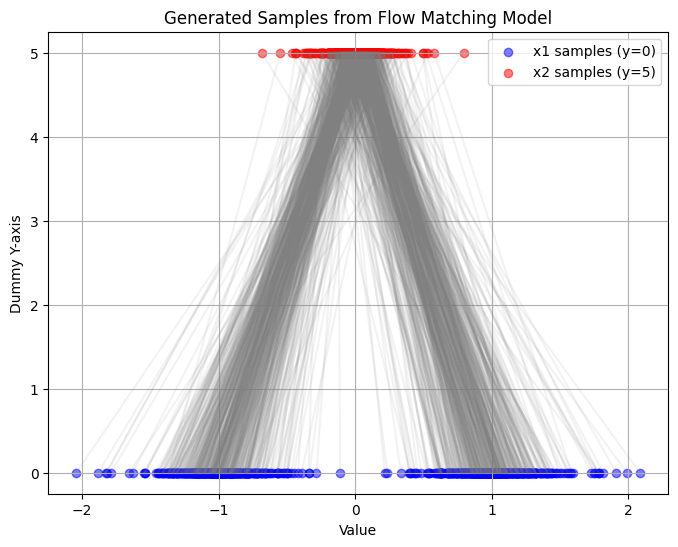

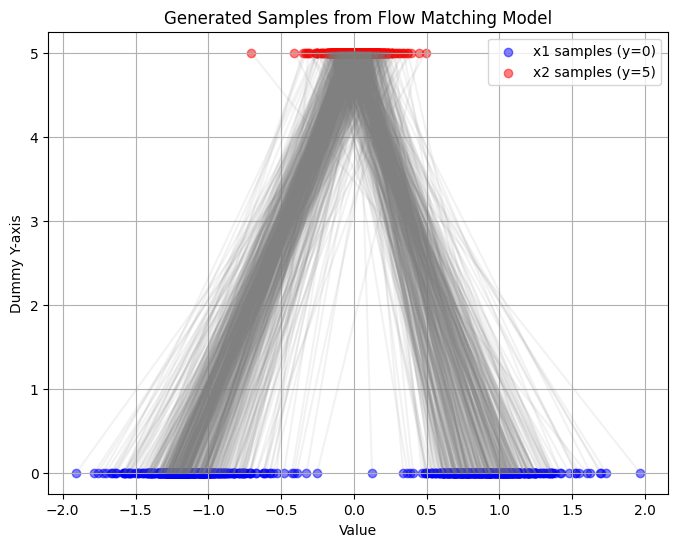

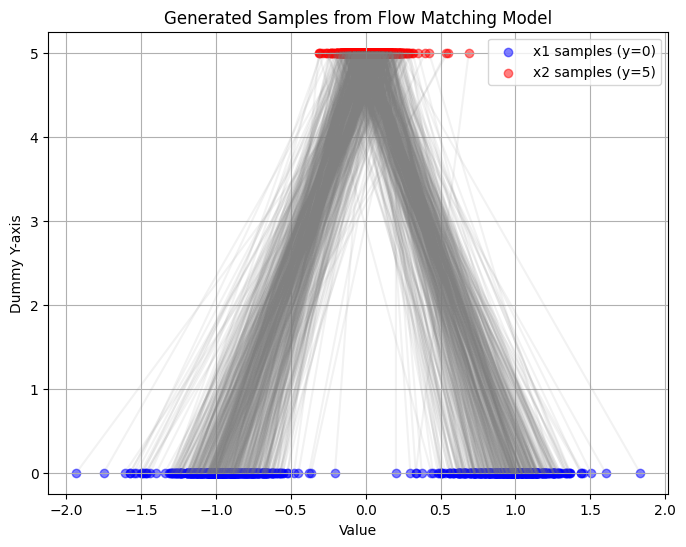

In [5]:
# Optional training loop for the flow matching model

from dataset import MultiModal2DDataset

print("Starting training loop...")
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Create dataset and dataloader
custom_matrix = np.array([
    [1],  # Mode 0 of x1 can pair with mode 0,1 of x2
    [1]
], dtype=bool)

dataset_custom = MultiModal2DDataset(
    num_samples=10000,
    num_modes_x1=2,
    num_modes_x2=1,
    mode_spacing_x1=2.0,
    mode_spacing_x2=1.5,
    mode_std_x1=0.2,
    mode_std_x2=0.1,
    transition_matrix=custom_matrix
)
dataloader = DataLoader(dataset_custom, batch_size=256, shuffle=True)

# Create model
model = create_flow_matching_model()

model.to(device)

# Training loop (simplified)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# make relevant directories
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("training", exist_ok=True)

num_epochs = 200
pbar = tqdm(range(num_epochs), desc="Loss: 0.0")

for epoch in pbar:
    for batch in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = model.training_step(batch)
        loss.backward()
        optimizer.step()

    pbar.set_description(f"Loss: {loss.item():.4f}")

    # save model
    if (epoch % 50 == 0 and epoch > 0) or epoch == num_epochs - 1:
        torch.save(model.state_dict(), "checkpoints/simple_flow_model.pth")

        # Sampling
        samples = model.sample(
            batch_size=1000,
            device=device,
            num_inference_steps=100
        )

        print("Generated samples shape:", samples.shape)

        # ploy x1 at y= 0 and x2 at y=5, join with lines
        import matplotlib.pyplot as plt
        x1_samples = samples[:, 0].cpu().numpy()
        x2_samples = samples[:, 1].cpu().numpy()
        plt.figure(figsize=(8, 6))
        plt.scatter(x1_samples, np.zeros_like(x1_samples), color='blue', alpha=0.5, label='x1 samples (y=0)')
        plt.scatter(x2_samples, np.ones_like(x2_samples) * 5, color='red', alpha=0.5, label='x2 samples (y=5)')
        for i in range(len(x1_samples)):
            plt.plot([x1_samples[i], x2_samples[i]], [0, 5], color='gray', alpha=0.1)
        plt.title('Generated Samples from Flow Matching Model')
        plt.xlabel('Value')
        plt.ylabel('Dummy Y-axis')
        plt.legend()
        plt.grid()
        plt.savefig(f"training/generated_samples_epoch_{epoch}.png")

## 4. Data Loading and Preprocessing

Now let's load our pre-trained model checkpoints. We have three types of models:
- **Model 1**: Edge model (first distribution)
- **Model 2**: Bridge model (intermediate distributions) 
- **Model 3**: Edge model (final distribution)

In [6]:
# Load pre-trained models
def load_models(device, model_paths, model_type, num_bridges=4):
    """
    Load pre-trained diffusion models for compositional sampling
    
    Args:
        device: torch device
        model_paths: dict with keys
            'start': path to first edge model
            'bridge': path to bridge model
            'end': path to second edge model
        model_type: 'diffusion' or 'flow'
        num_bridges: number of bridge models between edge models
    
    Returns:
        List of loaded models
    """
    assert model_type in ['diffusion', 'flow'], "model_type must be 'diffusion' or 'flow'"
    assert all(key in model_paths for key in ['start', 'bridge', 'end']), "model_paths must contain 'start', 'bridge', and 'end' keys"

    if model_type == 'diffusion':
        create_model_fn = create_simple_diffusion_model
    else:
        create_model_fn = create_flow_matching_model

    # Create model instances
    model_start = create_model_fn()  # Edge model start
    model_bridge = create_model_fn()  # Bridge model
    model_end = create_model_fn()  # Edge model end

    # Build model list: [edge] + [bridge]*num_bridges + [edge]
    models = [model_start] + [model_bridge] * num_bridges + [model_end]

    try:
        # Load pre-trained weights
        models[0].load_state_dict(torch.load(model_paths["start"], map_location=device))
        models[-1].load_state_dict(torch.load(model_paths["end"], map_location=device))

        # Load bridge models
        for model in models[1:-1]:
            model.load_state_dict(torch.load(model_paths["bridge"], map_location=device))
        
        # Move to device and set to eval mode
        for model in models:
            model.to(device)
            model.eval()
            
        print(f"✅ Successfully loaded {len(models)} models")
        return models
        
    except FileNotFoundError as e:
        print(f"❌ Model checkpoint not found: {e}")
        print("Note: You'll need pre-trained models to run the full demo")
        return None

# Create sliding window views
def create_views(num_models):
    """
    Create sliding 2D views over the latent space
    For M models, views are (0,2), (1,3), ..., (M-1, M+1)
    Total latent dimension = M+1
    """
    views = [(i, i + 2) for i in range(num_models)]
    print(f"Created {len(views)} views: {views}")
    print(f"Total latent dimension: {views[-1][1]}")
    return views

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Test diffusion model loading
num_bridges = 4
diffusion_model_paths = {
    "start": "./pretrained_checkpoints/simple_diffusion_model_start.pth",
    "bridge": "./pretrained_checkpoints/simple_diffusion_model_bridge.pth",
    "end": "./pretrained_checkpoints/simple_diffusion_model_end.pth"
}
models = load_models(device, diffusion_model_paths, 'diffusion', num_bridges)

# Test flow matching model loading
num_bridges = 4
flow_model_paths = {
    "start": "./pretrained_checkpoints/flow_matching_model_start.pth",
    "bridge": "./pretrained_checkpoints/flow_matching_model_bridge.pth",
    "end": "./pretrained_checkpoints/flow_matching_model_end.pth"
}
models = load_models(device, flow_model_paths, 'flow', num_bridges)

print("✅ Model loading function tested successfully!")

✅ Successfully loaded 6 models
✅ Successfully loaded 6 models
✅ Model loading function tested successfully!


 
## 5. CDGS Sampler Classes

This section introduces the core CDGS (Compositional Diffusion with Guided Search) sampler classes. These classes implement compositional inference-time algorithms for generating coherent long-horizon samples by combining multiple local models. The main variants are:

- **CDGS_wo_resampling_wo_pruning**: Base compositional sampler without resampling or pruning. Implements the compositional sampling logic.
- **CDGS_wo_pruning**: Adds iterative resampling to improve global coherence, but does not prune samples.
- **CDGS**: Full CDGS sampler with both iterative resampling and pruning based on local feasibility scores.

Each class builds on the previous, enabling flexible experimentation with different levels of compositional guidance. The samplers are compatible with both diffusion and flow-matching models, and use the loaded model checkpoints and scheduler defined above. Example usage and visualization utilities are provided in the following cells.

In [7]:
class CDGS_wo_resampling_wo_pruning(nn.Module):
    """
    CDGS base sampler (without resampling and without pruning).

    This class implements the core compositional sampling used by the 
    CDGS family of samplers. It maintains a list of per-local-plan models,
    constructs sliding-window local sequences over a long latent sequence, and
    produces compositional predictions by averaging overlapping model
    outputs on shared coordinates.

    Important properties:
    - `self.models`: list of model modules (one per view)
    - `self.views`: list of tuples indicating local plan start/end indices
    - `self.latent_dim`: total latent dimension (derived from views)

    Notes:
    - This implementation is intentionally minimal and focuses on clear,
      auditable inference steps. Extensions (resampling/pruning) are
      implemented in subclasses.
    """

    def __init__(self, model_paths, device, model_type='diffusion', num_bridges=1):
        """Initialize the CDGS base sampler.

        Args:
            model_paths: dictionary of model checkpoints
            device: torch device where models and sampling will run
            model_type: 'diffusion' or 'flow' (flow conversion handled elsewhere)
            num_bridges: number of bridge models to instantiate the task and 
                        corresponding local-model sequence
        """
        super().__init__()
        self.device = device

        # Load or use provided models; load_models returns a list or None
        self.model_type = model_type
        self.models = load_models(device, model_paths, model_type, num_bridges)

        # Build sliding-window views and latent dimensionality if models loaded
        if self.models:
            self.views = create_views(len(self.models))
            self.latent_dim = self.views[-1][1]
        else:
            raise ValueError("Models could not be loaded. Please check model paths.")

        # Initialize a DDPM scheduler used for all samplers. The scheduler
        # provides timesteps, noise schedules, and helper methods used
        # throughout the sampling code.
        self.scheduler = DDPMScheduler(
            num_train_timesteps=1000,
            beta_start=0.0001,
            beta_end=0.02,
            beta_schedule="linear",
            clip_sample=True,
        )

        print("✅ CDGS without pruning and resampling initialized:")
        print(f"  Model type: {self.model_type}")
        print(f"  Number of models: {len(self.models)}")
        print(f"  Views: {self.views}")
        print(f"  Latent dimension: {self.latent_dim}")
        print("  Sampling framework: diffusion (flow->eps conversion available in helpers)")

    def get_compositional_prediction(self, latent, t):
        """Compute compositional prediction by averaging overlapping view outputs.

        For each sliding view over the long latent sequence, the corresponding
        model predicts a residual/noise term. We accumulate predictions and
        normalize by the cover count to obtain a combined prediction defined
        on the full latent sequence.
        """
        count = torch.zeros_like(latent)
        value = torch.zeros_like(latent)

        B = latent.shape[0]

        # Ensure time is a tensor and shape (B,)
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=latent.dtype, device=self.device)
        t_vec = t.reshape(1).repeat(B).to(self.device)

        # Iterate through views and aggregate predictions
        for id, (start, end) in enumerate(self.views):
            latent_view = latent[:, start:end]
            pred = self.models[id](latent_view, t_vec)

            value[:, start:end] += pred
            count[:, start:end] += 1

        # Avoid division by zero: where count==0 keep zero
        combined_pred = torch.where(count > 0, value / count, value)
        return combined_pred

    @torch.no_grad()
    def sample(self, batch_size=100, num_inference_steps=100):
        """Basic sampling loop using compositional predictions and the DDPM scheduler.

        Args:
            batch_size: number of trajectories to sample
            num_inference_steps: steps for the denoising scheduler

        Returns:
            latent: sampled latent sequences (batch_size x latent_dim)
        """
        sequence_dim = self.views[-1][1]
        latent = torch.randn((batch_size, sequence_dim)).to(self.device)

        self.scheduler.set_timesteps(num_inference_steps)

        # Use autocast for potential performance improvements; behavior is preserved
        with torch.autocast(device_type=self.device):
            for i, t in enumerate(tqdm(self.scheduler.timesteps)):
                if self.model_type == 'diffusion':
                    eps_pred = self.get_compositional_prediction(latent, t)
                    output = self.scheduler.step(eps_pred, t, latent)
                    latent = output.prev_sample
                else:
                    # Flow-based sampling conversion is intentionally unimplemented
                    # in this base class — subclasses can provide concrete logic.
                    raise NotImplementedError("Flow model sampling not implemented yet")

        return latent

print("✅ CDGS_wo_resampling_wo_pruning class defined successfully!")

✅ CDGS_wo_resampling_wo_pruning class defined successfully!


In [8]:
# plotting utils

def plot_generated_samples(samples, views, class_name, num_inference_steps, seed):
    """Save generated latents to CSV and create overlay plots.

    This utility saves the sampled latent sequences into a CSV file with
    metadata columns and also generates a compact visualization where each
    latent dimension (x1, x2, ...) is plotted vertically with theoretical
    Gaussian overlays for quick qualitative inspection.

    Args:
        samples: numpy or torch array of shape (N, sequence_dim)
        views: list of sliding-window tuples used by the sampler
        class_name: descriptive name used for file naming and metadata
        num_inference_steps: number of diffusion steps used to generate samples
        seed: RNG seed used for reproducibility (saved in CSV metadata)
    """

    # Save latents to CSV file
    num_xs = len(views) + 1
    print("\nSaving latents to CSV file...")

    # Create DataFrame with appropriate column names
    column_names = [f'x{i+1}' for i in range(num_xs)]
    latents_df = pd.DataFrame(samples, columns=column_names)

    # Add metadata columns
    latents_df['mode'] = class_name
    latents_df['steps'] = num_inference_steps
    latents_df['seed'] = seed
    latents_df['num_bridges'] = len(views) - 2

    # Save to CSV
    csv_filename = f"results_notebook/latents_{class_name}_{num_inference_steps}steps_seed{seed}_bridges{len(views) - 2}.csv"
    latents_df.to_csv(csv_filename, index=False)
    print(f"Latents saved to: {csv_filename}")

    # Plot samples along horizontal axis with theoretical Gaussian overlays
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 8))

    # Plot scatter points for generated samples
    for i in range(num_xs):
        plt.scatter(np.ones_like(samples[:, i]) * i, samples[:, i], label=f'x{i+1} samples', alpha=0.5, s=20)

    # Determine y-range for plotting PDFs
    y_range = (samples.min() - 0.5, samples.max() + 0.5)
    y_points = np.linspace(y_range[0], y_range[1], 200)

    for i in range(num_xs):
        if i == 0:
            # First index: single Gaussian with mu=0, std=0.5
            mu, std = 0, 0.5
            gaussian_pdf = norm.pdf(y_points, mu, std)
            gaussian_scaled = i + gaussian_pdf * 0.3  # Scale factor to make it visible
            plt.plot(gaussian_scaled, y_points, 'b-', linewidth=2, alpha=0.8, label=f'x{i+1} theory (μ={mu}, σ={std})')

        elif i == num_xs - 1:
            # Last index: single Gaussian with mu=0, std=0.25
            mu, std = 0, 0.25
            gaussian_pdf = norm.pdf(y_points, mu, std)
            gaussian_scaled = i + gaussian_pdf * 0.3
            plt.plot(gaussian_scaled, y_points, 'g-', linewidth=2, alpha=0.8, label=f'x{i+1} theory (μ={mu}, σ={std})')

        else:
            # Middle indices: mixture of two Gaussians
            mu1, std1 = 0.75, 0.25
            mu2, std2 = -0.75, 0.25
            weight = 0.5  # Equal mixture

            gaussian1_pdf = norm.pdf(y_points, mu1, std1)
            gaussian2_pdf = norm.pdf(y_points, mu2, std2)
            mixture_pdf = weight * gaussian1_pdf + weight * gaussian2_pdf

            mixture_scaled = i + mixture_pdf * 0.3
            plt.plot(mixture_scaled, y_points, 'purple', linewidth=2, alpha=0.8, label=f'x{i+1} theory (mixture)')

    # Plot a small subset of trajectory lines for qualitative inspection
    for i in range(min(samples.shape[0] - 1, 50)):
        plt.plot(range(num_xs), samples[i], color='gray', alpha=0.1, linewidth=0.5)

    plt.title(f'Generated samples vs theoretical distributions after {num_inference_steps} steps of {class_name} inference')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figures_notebook/long_{class_name}_samples_{seed}_steps_{num_inference_steps}.png", dpi=150, bbox_inches='tight')
    plt.close()


In [10]:
# Test CDGS_wo_resampling_wo_pruning

num_samples_to_generate = 1000
num_inference_steps = 100
seed = 42
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
num_bridges = 10
seed_everything(seed)

diffusion_model_paths = {
    "start": "./pretrained_checkpoints/simple_diffusion_model_start.pth",
    "bridge": "./pretrained_checkpoints/simple_diffusion_model_bridge.pth",
    "end": "./pretrained_checkpoints/simple_diffusion_model_end.pth"
}

sampler = CDGS_wo_resampling_wo_pruning(
    model_paths=diffusion_model_paths,
    device=device,
    model_type='diffusion',
    num_bridges=num_bridges
)

samples = sampler.sample(batch_size=num_samples_to_generate, num_inference_steps=num_inference_steps)
print("Generated samples shape (diffusion):", samples.shape)

plot_generated_samples(
    samples.cpu().numpy(), 
    sampler.views, 
    class_name=f"{sampler.__class__.__name__}_diffusion", 
    num_inference_steps=num_inference_steps,
    seed=seed
)

✅ Successfully loaded 12 models
Created 12 views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12), (11, 13)]
Total latent dimension: 13
✅ CDGS without pruning and resampling initialized:
  Model type: diffusion
  Number of models: 12
  Views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12), (11, 13)]
  Latent dimension: 13
  Sampling framework: diffusion (flow->eps conversion available in helpers)


100%|██████████| 100/100 [00:06<00:00, 14.92it/s]


Generated samples shape (diffusion): torch.Size([1000, 13])

Saving latents to CSV file...
Latents saved to: results_notebook/latents_CDGS_wo_resampling_wo_pruning_diffusion_100steps_seed42_bridges10.csv


In [11]:
class CDGS_wo_pruning(CDGS_wo_resampling_wo_pruning):
    """
    CDGS sampler with resampling but without pruning. The iterative resampling
    loop is implemented in the sample() method, while the undo_step() method
    reverses a diffusion step to return to the previous noisy state.
    """
    
    def __init__(self, model_paths, device, model_type='diffusion', num_bridges=1, num_resampling_steps=5):
        """
        Initialize unified diffusion compositional sampler
        
        Args:
            model_paths: Dictionary of model checkpoint paths
            device: torch device
            model_type: 'diffusion' or 'flow'
            num_bridges: number of bridge models (if loading from scratch)
        """
        super().__init__(model_paths, device, model_type, num_bridges)
        self.num_resampling_steps = num_resampling_steps

        print(f"✅ CDGS without pruning initialized with {self.num_resampling_steps} iterative resampling steps")

    def undo_step(self, latents, timestep, scheduler, generator=None):
        n = scheduler.config.num_train_timesteps // scheduler.num_inference_steps

        for i in range(n):
            beta = scheduler.betas[timestep + i]
            if latents.device.type == "mps":
                # randn does not work reproducibly on mps
                noise = randn_tensor(latents.shape, dtype=latents.dtype, generator=generator)
                noise = noise.to(latents.device)
            else:
                noise = randn_tensor(latents.shape, generator=generator, device=latents.device, dtype=latents.dtype)

            # 10. Algorithm 1 Line 10 https://huggingface.co/papers/2201.09865
            latents = (1 - beta) ** 0.5 * latents + beta**0.5 * noise

        return latents
        
    @torch.no_grad()
    def sample(self, batch_size=100, num_inference_steps=100):

        sequence_dim = self.views[-1][1]
        latent = torch.randn((batch_size, sequence_dim)).to(self.device)

        self.scheduler.set_timesteps(num_inference_steps)

        with torch.autocast(device_type=self.device):
            for i, t in enumerate(tqdm(self.scheduler.timesteps)):
                for u in range(self.num_resampling_steps):
                    if self.model_type == 'diffusion':
                        eps_pred = self.get_compositional_prediction(latent, t)
                        output = self.scheduler.step(eps_pred, t, latent)
                        latent = output.prev_sample
                    else:  # flow model
                        raise NotImplementedError("Flow model sampling not implemented yet")
                    
                    if u < self.num_resampling_steps-1 and i < len(self.scheduler.timesteps)-1 and i > 0:
                        # undo the diffusion step to return to x_t
                        latent = self.undo_step(latent, t, self.scheduler)
        return latent

In [12]:
# Test CDGS_wo_pruning

num_samples_to_generate = 1000
num_inference_steps = 100
seed = 42
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
num_bridges = 10
num_resampling_steps = 10
seed_everything(seed)

diffusion_model_paths = {
    "start": "./pretrained_checkpoints/simple_diffusion_model_start.pth",
    "bridge": "./pretrained_checkpoints/simple_diffusion_model_bridge.pth",
    "end": "./pretrained_checkpoints/simple_diffusion_model_end.pth"
}

sampler = CDGS_wo_pruning(
    model_paths=diffusion_model_paths,
    device=device,
    model_type='diffusion',
    num_bridges=num_bridges,
    num_resampling_steps=num_resampling_steps
)

samples = sampler.sample(batch_size=num_samples_to_generate, num_inference_steps=num_inference_steps)
print("Generated samples shape (diffusion):", samples.shape)

plot_generated_samples(
    samples.cpu().numpy(), 
    sampler.views, 
    class_name=f"{sampler.__class__.__name__}_diffusion", 
    num_inference_steps=num_inference_steps,
    seed=seed
)

✅ Successfully loaded 12 models
Created 12 views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12), (11, 13)]
Total latent dimension: 13
✅ CDGS without pruning and resampling initialized:
  Model type: diffusion
  Number of models: 12
  Views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12), (11, 13)]
  Latent dimension: 13
  Sampling framework: diffusion (flow->eps conversion available in helpers)
✅ CDGS without pruning initialized with 10 iterative resampling steps


100%|██████████| 100/100 [00:57<00:00,  1.73it/s]


Generated samples shape (diffusion): torch.Size([1000, 13])

Saving latents to CSV file...
Latents saved to: results_notebook/latents_CDGS_wo_pruning_diffusion_100steps_seed42_bridges10.csv


In [14]:
class CDGS(CDGS_wo_pruning):
    """
    CDGS sampler with both resampling and pruning. The pruning step is
    implemented in the inversion_pruning() method, which rearranges the
    latent batch based on inversion scores computed from the predicted
    clean samples. The sample() method integrates pruning into the
    iterative resampling loop.
    """
    
    def __init__(self, model_paths, device, model_type='diffusion', num_bridges=1, num_resampling_steps=5, pruning_start_end=[0.1, 0.9], pruning_top_K=0.2):
        super().__init__(model_paths, device, model_type, num_bridges, num_resampling_steps)
        self.pruning_start = pruning_start_end[0]
        self.pruning_end = pruning_start_end[1]
        self.pruning_top_K = pruning_top_K

        print(f"✅ CDGS initialized with pruning from {self.pruning_start} to {self.pruning_end} and top-K {self.pruning_top_K}")

    def inversion_pruning(self, pred_x0, latents, views, top_K, return_scores=False):
        """
        Rearrange the latent batch based on inversion scores computed from
        the predicted clean samples using a DDIM-inversion procedure. DDIM inversion
        is used to calculate the rate of change of score along the noising trajectory,
        which indicates the smoothness of each sample's inversion path. A smoother
        inversion path is interpreted as indicating a higher-likelihood local plan segment.

        The top-K samples with the lowest scores (most-smooth) are retained,
        and the batch is rearranged accordingly.

        Args:
            pred_x0: predicted clean samples (B, latent_dim)
            latents: current noisy latents (B, latent_dim)
            views: list of sliding-window tuples
            top_K: fraction of samples to retain (0 < top_K <= 1)
            return_scores: if True, return the scores along with rearranged batch
    
        Returns:
            arranged_batch: rearranged latent batch (B, latent_dim)
            final_scores (optional): inversion scores for each sample (B,)
        """
        # Implement the inversion pruning logic here
        num_models = len(views)
        B = pred_x0.shape[0]
        all_timesteps = self.scheduler.timesteps.flip(dims=(0,))
        num_timesteps = len(all_timesteps)

        batched_x0s = []
        for start, end in views:
            batched_x0s.append(pred_x0[:, start:end])

        batched_x0s = torch.stack(batched_x0s, dim=0)  # [num_models, B, 2]

        inversion_latents = batched_x0s.clone()
        all_noise_prediction = []

        # for idx, i in tqdm(enumerate(all_timesteps[:-1]), leave=False, total=len(all_timesteps)-1):
        for idx, i in tqdm(enumerate(all_timesteps[:-int(num_timesteps * (0.95))+1]), leave=False, total=num_timesteps//20):
            t = i
            t_next = all_timesteps[idx + 1]
            alpha_t = self.scheduler.alphas_cumprod[t]
            alpha_t_next = self.scheduler.alphas_cumprod[t_next]
            sqrt_alpha_t = torch.sqrt(alpha_t)
            sqrt_alpha_t_next = torch.sqrt(alpha_t_next)
            sqrt_one_minus_alpha_t = torch.sqrt(1 - alpha_t)
            sqrt_one_minus_alpha_t_next = torch.sqrt(1 - alpha_t_next)

            with torch.no_grad():
                noise_pred_combined = torch.zeros_like(inversion_latents)
                for id, (start, end) in enumerate(views):
                    latent_view = inversion_latents[id]
                    noise_pred = self.models[id](latent_view, t.repeat(B).to(self.device))
                    noise_pred_combined[id] = noise_pred

                x0_pred = (inversion_latents - sqrt_one_minus_alpha_t * noise_pred_combined) / sqrt_alpha_t
                x0_pred = torch.clamp(x0_pred, -1.0, 1.0)
                noise_pred_combined = (inversion_latents - sqrt_alpha_t * x0_pred) / sqrt_one_minus_alpha_t
                inversion_latents = sqrt_alpha_t_next * x0_pred + sqrt_one_minus_alpha_t_next * noise_pred_combined
                all_noise_prediction.append(noise_pred_combined)

        all_intermediate_noise_preds = torch.stack(all_noise_prediction, dim=2) # [num_models, B, num_inference_steps, 2]
        derivative = torch.diff(all_intermediate_noise_preds, dim=2)

        all_scores = torch.norm(derivative.reshape(num_models*B, -1), dim=1).reshape(num_models, B)
        final_scores = all_scores.mean(dim=0) # (B,)

        num_selected_samples = max(int(top_K * B), 1)
        topk_indices = torch.topk(final_scores, k = num_selected_samples, largest=False)[1]

        arranged_batch = latents.clone()
        arranged_batch = arranged_batch[topk_indices]

        while arranged_batch.shape[0] < B:
            arranged_batch = torch.cat([arranged_batch, arranged_batch], dim=0)

        arranged_batch = arranged_batch[:B]

        if return_scores:
            return latents, final_scores

        return arranged_batch
    
    @torch.no_grad()
    def sample(self, batch_size=100, num_inference_steps=100):

        sequence_dim = self.views[-1][1]
        latent = torch.randn((batch_size, sequence_dim)).to(self.device)

        self.scheduler.set_timesteps(num_inference_steps)
        num_timesteps = len(self.scheduler.timesteps)

        with torch.autocast(device_type=self.device):
            for i, t in enumerate(tqdm(self.scheduler.timesteps)):
                for u in range(self.num_resampling_steps):
                    if self.model_type == 'diffusion':
                        eps_pred = self.get_compositional_prediction(latent, t)
                        output = self.scheduler.step(eps_pred, t, latent)
                        pred_x0 = output.pred_original_sample
                        latent = output.prev_sample
                    else:  # flow model
                        raise NotImplementedError("Flow model sampling not implemented yet")

                    if u == self.num_resampling_steps-2 and (i < self.pruning_end*num_timesteps and i > self.pruning_start*num_timesteps):
                        latent = self.inversion_pruning(
                            pred_x0,
                            latent,
                            self.views,
                            self.pruning_top_K
                        )
                    
                    if u < self.num_resampling_steps-1 and i < len(self.scheduler.timesteps)-1 and i > 0:
                        # undo the diffusion step to return to x_t
                        latent = self.undo_step(latent, t, self.scheduler)
        return latent

In [15]:
# Test CDGS (full pipeline run used to reproduce paper figures)
#
# This example demonstrates sampling from the full CDGS pipeline (CDGS
# with pruning/resampling enabled) using pre-trained diffusion checkpoints
# located under `models/`. It is intended for offline reproduction of the
# paper figures and therefore may require the model files present in the
# repository.

num_samples_to_generate = 1000
num_inference_steps = 100
seed = 42
# Select compute device: prefer GPU, then MPS, then CPU
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
num_bridges = 10
num_resampling_steps = 10
pruning_start_end = [0.0, 1.0]
pruning_top_K = 0.2
seed_everything(seed)

# Paths to pre-trained diffusion checkpoints (expected to exist locally)
diffusion_model_paths = {
    "start": "./pretrained_checkpoints/simple_diffusion_model_start.pth",
    "bridge": "./pretrained_checkpoints/simple_diffusion_model_bridge.pth",
    "end": "./pretrained_checkpoints/simple_diffusion_model_end.pth",
}

# Initialize the sampler (this will load models and prepare views/scheduler)
sampler = CDGS(
    model_paths=diffusion_model_paths,
    device=device,
    model_type='diffusion',
    num_bridges=num_bridges,
    num_resampling_steps=num_resampling_steps,
    pruning_start_end=pruning_start_end,
    pruning_top_K=pruning_top_K,
)

# Run the sampling pipeline (this step can be expensive and requires the checkpoints)
samples = sampler.sample(batch_size=num_samples_to_generate, num_inference_steps=num_inference_steps)
print("Generated samples shape (diffusion):", samples.shape)

# Save and visualize results
plot_generated_samples(
    samples.cpu().numpy(),
    sampler.views,
    class_name=f"{sampler.__class__.__name__}_diffusion",
    num_inference_steps=num_inference_steps,
    seed=seed,
)


✅ Successfully loaded 12 models
Created 12 views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12), (11, 13)]
Total latent dimension: 13
✅ CDGS without pruning and resampling initialized:
  Model type: diffusion
  Number of models: 12
  Views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10), (9, 11), (10, 12), (11, 13)]
  Latent dimension: 13
  Sampling framework: diffusion (flow->eps conversion available in helpers)
✅ CDGS without pruning initialized with 10 iterative resampling steps
✅ CDGS initialized with pruning from 0.0 to 1.0 and top-K 0.2


100%|██████████| 100/100 [01:38<00:00,  1.01it/s]


Generated samples shape (diffusion): torch.Size([1000, 13])

Saving latents to CSV file...
Latents saved to: results_notebook/latents_CDGS_diffusion_100steps_seed42_bridges10.csv
